<a href="https://colab.research.google.com/github/kalyaninivant/Digital_Image_Processing-/blob/main/Point_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

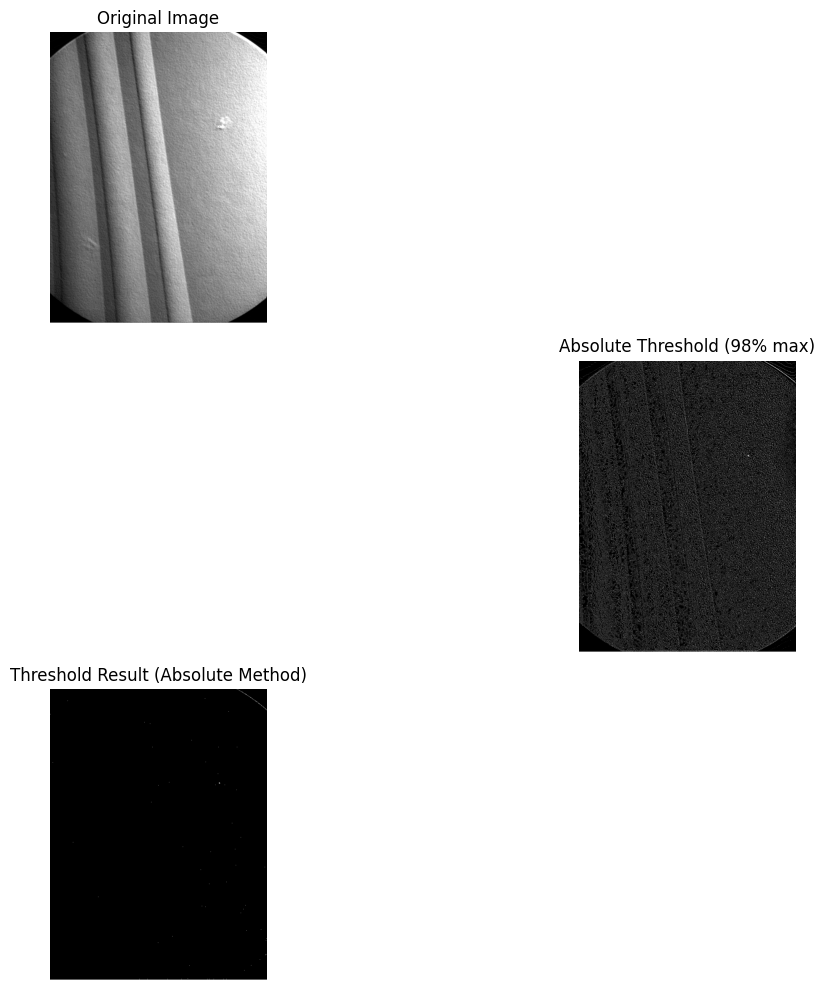

In [ ]:
import cv2
import numpy as np
from matplotlib import pyplot as plt


img_point = cv2.imread('/content/Point.tif', 0)


kernel_point = np.array([[-1,-1,-1],
                         [-1, 8,-1],
                         [-1,-1,-1]])


point = cv2.filter2D(img_point, -1, kernel_point)
ret, point_thresh = cv2.threshold(point, 10, 255, cv2.THRESH_BINARY)





point_abs = np.abs(point)

max_val = np.max(point_abs)
threshold_value = 0.98 * max_val


point_abs_norm = cv2.normalize(point_abs, None, 0, 255, cv2.NORM_MINMAX)
point_abs_norm = point_abs_norm.astype(np.uint8)

ret2, point_thresh_abs = cv2.threshold(point_abs_norm, int(threshold_value * 255 / max_val), 255, cv2.THRESH_BINARY)


plt.figure(figsize=(12,10))

# Original
plt.subplot(3,2,1)
plt.title("Original Image")
plt.imshow(img_point, cmap='gray')
plt.axis('off')



# Method 2
plt.subplot(3,2,4)
plt.title("Absolute Threshold (98% max)")
plt.imshow(point_abs_norm, cmap='gray')
plt.axis('off')

plt.subplot(3,2,5)
plt.title("Threshold Result (Absolute Method)")
plt.imshow(point_thresh_abs, cmap='gray')
plt.axis('off')

plt.tight_layout()
plt.show()